In [ ]:
!pip install requests beautifulsoup4 pandas

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "http://books.toscrape.com/"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

books = soup.find_all("article", class_="product_pod")

data = []

for book in books:
    title = book.h3.a["title"]
    price = book.find("p", class_="price_color").text
    availability = book.find("p", class_="instock availability").text.strip()

    data.append([title, price, availability])

df_scraped = pd.DataFrame(data, columns=["Title", "Price", "Availability"])

df_scraped.head()

,Title,Price,Availability
0,A Light in the Attic,Â£51.77,In stock
1,Tipping the Velvet,Â£53.74,In stock
2,Soumission,Â£50.10,In stock
3,Sharp Objects,Â£47.82,In stock
4,Sapiens: A Brief History of Humankind,Â£54.23,In stock


In [ ]:
df_scraped.to_csv("scraped_books.csv", index=False)
print("Task 1 Completed ✅")

Task 1 Completed ✅


In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

In [ ]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
# Add missing values (for demo)
df.iloc[0,0] = np.nan
df.iloc[10,2] = np.nan

print(df.isnull().sum())

# Fill with mean
df.fillna(df.mean(numeric_only=True), inplace=True)

print("Missing Values Handled ✅")

sepal length (cm)    1
sepal width (cm)     0
petal length (cm)    1
petal width (cm)     0
species              0
dtype: int64
Missing Values Handled ✅


In [ ]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Outliers Removed ✅")

Outliers Removed ✅


In [ ]:
scaler = StandardScaler()
features = df.columns[:-1]

df[features] = scaler.fit_transform(df[features])

df.head()
print("Task 2 Completed ✅")

Task 2 Completed ✅


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,1.460000e+02,1.460000e+02,1.460000e+02,1.460000e+02,146.000000
mean,-8.760116e-16,-2.068361e-15,-1.703356e-15,-9.246789e-16,1.020548
std,1.003442e+00,1.003442e+00,1.003442e+00,1.003442e+00,0.817643
min,-1.884502e+00,-2.119639e+00,-1.620673e+00,-1.480662e+00,0.000000
25%,-9.193125e-01,-6.063515e-01,-1.276144e+00,-1.216388e+00,0.000000
50%,-7.477179e-02,-1.019223e-01,3.316553e-01,1.049858e-01,1.000000
75%,6.491203e-01,6.547214e-01,7.336052e-01,7.656726e-01,2.000000
max,2.458850e+00,2.420223e+00,1.767191e+00,1.690634e+00,2.000000


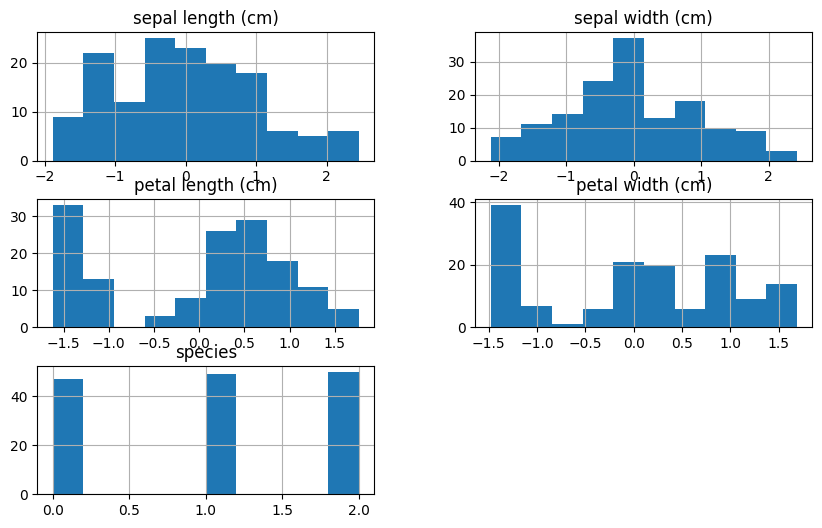

In [ ]:
df.hist(figsize=(10,6))
plt.show()

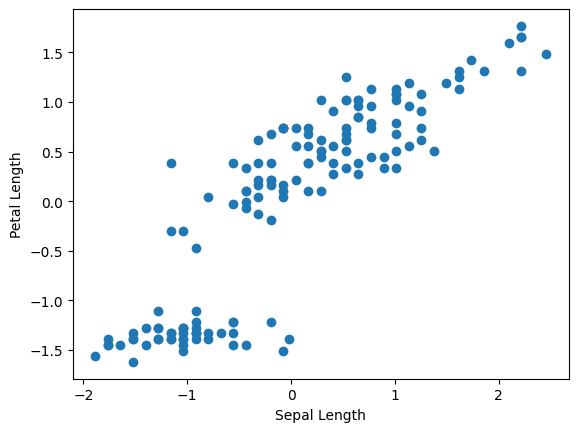

In [ ]:
plt.scatter(df["sepal length (cm)"], df["petal length (cm)"])
plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.show()

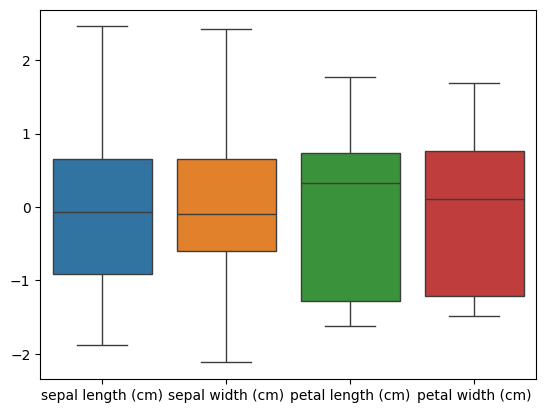

In [ ]:
sns.boxplot(data=df.iloc[:,:4])
plt.show()

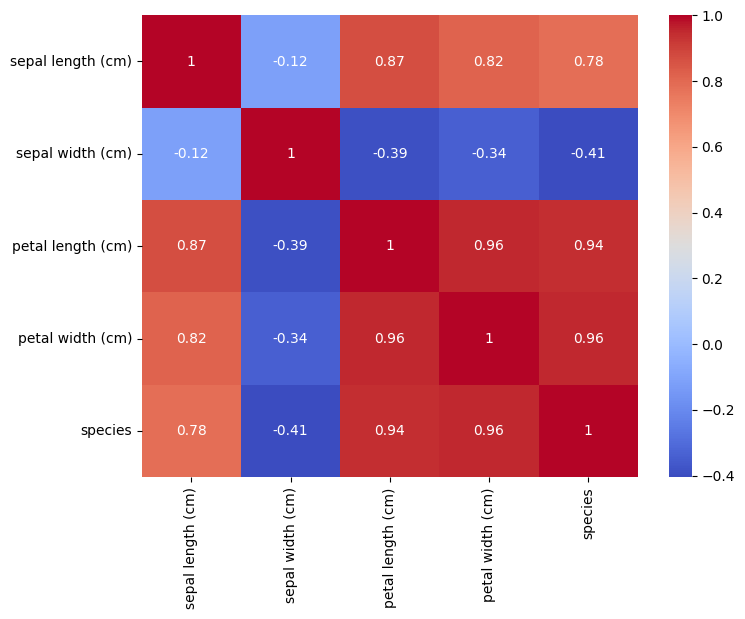

Task 3 Completed ✅


In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

print("Task 3 Completed ✅")